# Chapter 70 — Function Families

> **Prerequisites:** ch058–069 (all function types and transformations)
>
> **You will learn:**
> - Organize function types into parameterized families
> - Understand how a single template generates many functions
> - Connect to model selection: choosing the right function family
> - Build a classification system for common mathematical functions
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **function family** is a set of functions sharing the same structural form, differentiated only by parameters.

Examples:
- **Power family:** f(x) = xⁿ, parameterized by n
- **Exponential family:** f(x) = aˣ, parameterized by base a
- **Sinusoidal family:** f(x) = A·sin(ωx + φ), parameterized by amplitude A, frequency ω, phase φ
- **Logistic family:** f(x) = L/(1 + e^(-k(x-x₀))), parameterized by L, k, x₀
- **Gaussian family:** f(x) = (1/σ√2π)·e^(-(x-μ)²/2σ²), parameterized by μ, σ

**Model selection** is the problem of choosing which function family to use. Choose a family too simple (linear when the data is quadratic) and you underfit. Choose one too complex and you overfit.

The right family encodes your *prior knowledge* about the structure of the relationship you're modeling.

---

## 2. Intuition & Mental Models

**Physical analogy:** Tool families. A screwdriver family: flat, Phillips, Torx — same concept, different parameterization. You choose the family based on the screw type, then pick the parameter (size).

**Computational analogy:** Class hierarchies. A `Model` base class with `LinearModel`, `PolynomialModel`, `LogisticModel` subclasses. Each subclass is a function family; the parameters are the fitted coefficients.

---

## 3. Visualization

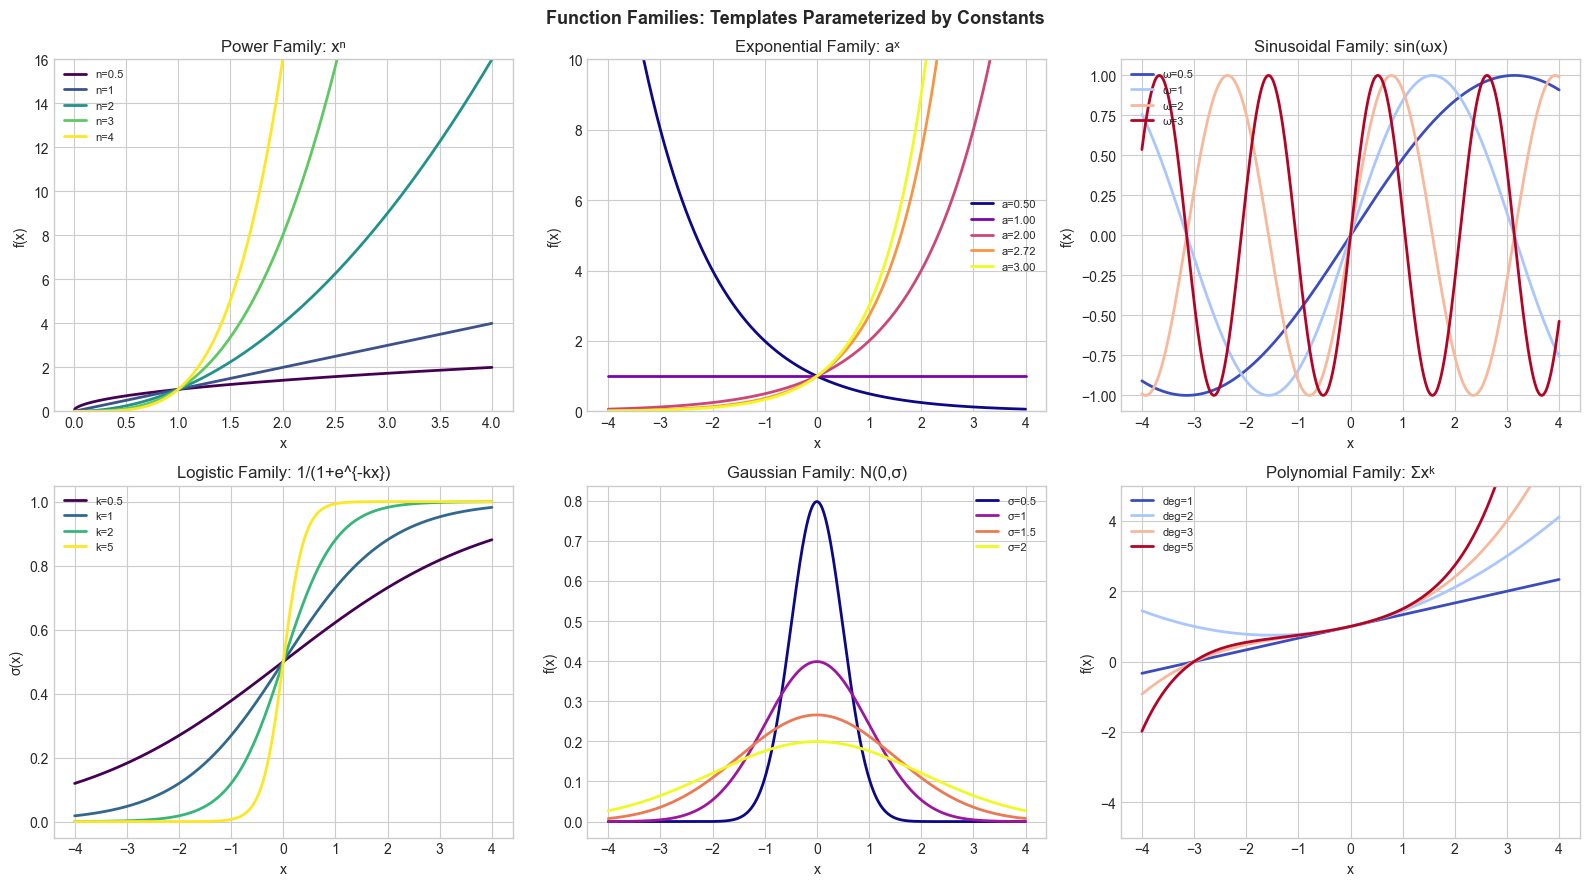

In [1]:
# --- Visualization: Function families and their shapes ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-4, 4, 500)
x_pos = np.linspace(0.01, 4, 500)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Power family
ax = axes[0, 0]
for n, color in zip([0.5, 1, 2, 3, 4], plt.cm.viridis(np.linspace(0, 1, 5))):
    ax.plot(x_pos, x_pos**n, color=color, linewidth=2, label=f'n={n}')
ax.set_title('Power Family: xⁿ'); ax.legend(fontsize=8); ax.set_ylim(0, 16)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# Exponential family
ax = axes[0, 1]
for a, color in zip([0.5, 1, 2, np.e, 3], plt.cm.plasma(np.linspace(0, 1, 5))):
    ax.plot(x, a**x, color=color, linewidth=2, label=f'a={a:.2f}')
ax.set_title('Exponential Family: aˣ'); ax.legend(fontsize=8); ax.set_ylim(0, 10)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# Sinusoidal family (varying frequency)
ax = axes[0, 2]
for omega, color in zip([0.5, 1, 2, 3], plt.cm.coolwarm(np.linspace(0, 1, 4))):
    ax.plot(x, np.sin(omega * x), color=color, linewidth=2, label=f'ω={omega}')
ax.set_title('Sinusoidal Family: sin(ωx)'); ax.legend(fontsize=8)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# Logistic family (varying k)
ax = axes[1, 0]
for k, color in zip([0.5, 1, 2, 5], plt.cm.viridis(np.linspace(0, 1, 4))):
    ax.plot(x, 1/(1+np.exp(-k*x)), color=color, linewidth=2, label=f'k={k}')
ax.set_title('Logistic Family: 1/(1+e^{-kx})'); ax.legend(fontsize=8)
ax.set_xlabel('x'); ax.set_ylabel('σ(x)')

# Gaussian family (varying σ)
ax = axes[1, 1]
for sigma, color in zip([0.5, 1, 1.5, 2], plt.cm.plasma(np.linspace(0, 1, 4))):
    g = np.exp(-x**2/(2*sigma**2)) / (sigma * np.sqrt(2*np.pi))
    ax.plot(x, g, color=color, linewidth=2, label=f'σ={sigma}')
ax.set_title('Gaussian Family: N(0,σ)'); ax.legend(fontsize=8)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# Polynomial family
ax = axes[1, 2]
for deg, color in zip([1, 2, 3, 5], plt.cm.coolwarm(np.linspace(0, 1, 4))):
    coeffs = np.ones(deg+1)
    y = np.polyval(coeffs, x/3)
    ax.plot(x, np.clip(y, -5, 5), color=color, linewidth=2, label=f'deg={deg}')
ax.set_title('Polynomial Family: Σxᵏ'); ax.legend(fontsize=8); ax.set_ylim(-5, 5)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')

plt.suptitle('Function Families: Templates Parameterized by Constants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Function family selector ---
import numpy as np

FUNCTION_FAMILIES = {
    'linear':      {'fn': lambda x, m, b: m*x + b,
                    'params': ['slope m', 'intercept b'],
                    'domain': 'all reals', 'bounded': False},
    'power':       {'fn': lambda x, n: x**n,
                    'params': ['exponent n'],
                    'domain': 'x>0 for non-integer n', 'bounded': False},
    'exponential': {'fn': lambda x, a, b: b * np.exp(a * x),
                    'params': ['rate a', 'scale b'],
                    'domain': 'all reals', 'bounded': 'lower only'},
    'logistic':    {'fn': lambda x, L, k, x0: L / (1 + np.exp(-k*(x-x0))),
                    'params': ['capacity L', 'growth k', 'midpoint x0'],
                    'domain': 'all reals', 'bounded': '(0, L)'},
    'sinusoidal':  {'fn': lambda x, A, omega, phi: A * np.sin(omega*x + phi),
                    'params': ['amplitude A', 'frequency ω', 'phase φ'],
                    'domain': 'all reals', 'bounded': '[-A, A]'},
    'gaussian':    {'fn': lambda x, mu, sigma: np.exp(-(x-mu)**2/(2*sigma**2)),
                    'params': ['mean μ', 'std σ'],
                    'domain': 'all reals', 'bounded': '(0, 1]'},
}

print("Available function families:")
for name, info in FUNCTION_FAMILIES.items():
    print(f"  {name:12s}: params={info['params']}, domain={info['domain']}")

# Model selection heuristic
def suggest_family(data_y, data_x=None):
    """Heuristic family suggestion based on data characteristics."""
    y = np.asarray(data_y)
    is_bounded = (y.min() >= 0) and (y.max() <= 1.01)
    is_monotone = np.all(np.diff(y) >= 0) or np.all(np.diff(y) <= 0)
    grows_fast = y[-1] / max(y[0], 1e-10) > 10
    
    if is_bounded and is_monotone: return 'logistic'
    if grows_fast and is_monotone: return 'exponential'
    if is_monotone: return 'power or linear'
    return 'sinusoidal or polynomial'

# Test
np.random.seed(0)
print("\nFamily suggestions:")
print("  Sigmoid-shaped data:", suggest_family(1/(1+np.exp(-np.linspace(-4,4,50)))))
print("  Exponential data:   ", suggest_family(np.exp(np.linspace(0,3,50))))
print("  Oscillating data:   ", suggest_family(np.sin(np.linspace(0,4*np.pi,50))))

Available function families:
  linear      : params=['slope m', 'intercept b'], domain=all reals
  power       : params=['exponent n'], domain=x>0 for non-integer n
  exponential : params=['rate a', 'scale b'], domain=all reals
  logistic    : params=['capacity L', 'growth k', 'midpoint x0'], domain=all reals
  sinusoidal  : params=['amplitude A', 'frequency ω', 'phase φ'], domain=all reals
  gaussian    : params=['mean μ', 'std σ'], domain=all reals

Family suggestions:
  Sigmoid-shaped data: logistic
  Exponential data:    exponential
  Oscillating data:    sinusoidal or polynomial


---

## 6. Experiments

**Experiment 1:** Generate data from a logistic curve with noise. Try fitting it with a linear, quadratic, and logistic model. Which gives the lowest error? Which generalizes best?

**Experiment 2:** For the sinusoidal family A·sin(ωx+φ), show that changing φ shifts the curve horizontally. What value of φ makes it equivalent to a cosine?

---

## 7. Exercises

**Easy 1.** Which function family would you use to model: (a) compound interest, (b) population with carrying capacity, (c) daily temperature over a year? Justify each.

**Easy 2.** The Gaussian family is parameterized by μ and σ. Write a function `gaussian(mu, sigma)` that returns a callable f(x). Use it to create three Gaussians and plot them.

**Medium 1.** Implement a `FunctionFamily` class that stores parameter names and a template function, provides a `sample_member(param_dict)` method returning a callable, and a `plot_family(ax, param_grid)` that overlays multiple members.

**Medium 2.** Given a dataset (x, y), implement a function that tests all 6 families in `FUNCTION_FAMILIES` by fitting parameters via grid search and returns the family with lowest residual sum of squares.

**Hard.** The exponential family in statistics (not the same as base-a exponentials) has the form f(x; θ) = h(x)·exp(θᵀT(x) - A(θ)). Show that the Gaussian, Bernoulli, and Poisson distributions are all members of this family by identifying h, T, and A for each.

---

## 9. Chapter Summary & Connections

- A function family is a parameterized template: one formula, infinitely many functions
- Model selection = choosing the right family; fitting = choosing the right parameters
- Key families: power, exponential, logistic, sinusoidal, Gaussian, polynomial
- Over-parameterized families lead to overfitting; under-parameterized to underfitting

**Backward connection:** Every function type in ch058–064 is a family with its own parameters.

**Forward connections:**
- ch072 (Fitting Simple Models) fits parameters within a chosen family
- ch286 (Regression) and ch293 (Classification) are formal model selection problems
- Exponential families in statistics (ch282) use the same concept in probability